In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, 
    classification_report,
    RocCurveDisplay)

In [4]:
df = pd.read_csv('deliriumwatch_clean_V5.csv')

In [5]:
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("NaN after fix:", df.isnull().sum().sum())


NaN after fix: 0


In [6]:
X = df.drop(columns=['delirium_label'])
y = df['delirium_label']

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Features shape: (25843, 27)
Target distribution:
delirium_label
0    14028
1    11815
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

AUROC: 0.7655

Classification Report:
              precision    recall  f1-score   support

 No Delirium       0.72      0.72      0.72      2806
    Delirium       0.67      0.68      0.67      2363

    accuracy                           0.70      5169
   macro avg       0.70      0.70      0.70      5169
weighted avg       0.70      0.70      0.70      5169



C:\Users\basav\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


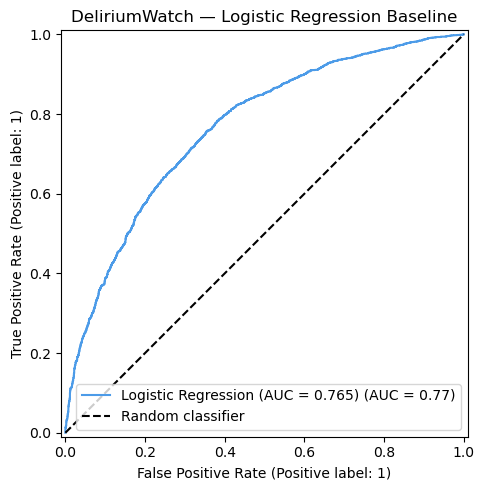

In [9]:
# Logistic Regression baseline
lr = LogisticRegression(
    class_weight='balanced',  # handles 64/36 imbalance
    max_iter=1000,            # enough iterations to converge
    random_state=42
)

lr.fit(X_train_scaled, y_train)

# Predict probabilities (not just 0/1)
# AUROC needs probabilities, not hard predictions
y_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]
y_pred = lr.predict(X_test_scaled)

# Metrics
auroc = roc_auc_score(y_test, y_pred_proba)
print(f"AUROC: {auroc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['No Delirium', 'Delirium']))

# ROC Curve
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test, y_pred_proba,
    name=f"Logistic Regression (AUC = {auroc:.3f})",
    ax=ax, color='#4C9BE8'
)
ax.plot([0,1],[0,1],'k--', label='Random classifier')
ax.set_title('DeliriumWatch — Logistic Regression Baseline')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=14028/11815,  # handles class imbalance
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb.predict(X_test)



In [11]:
auroc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"XGBoost AUROC: {auroc_xgb:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['No Delirium', 'Delirium']))

XGBoost AUROC: 0.8393

Classification Report:
              precision    recall  f1-score   support

 No Delirium       0.77      0.79      0.78      2806
    Delirium       0.74      0.72      0.73      2363

    accuracy                           0.76      5169
   macro avg       0.76      0.76      0.76      5169
weighted avg       0.76      0.76      0.76      5169



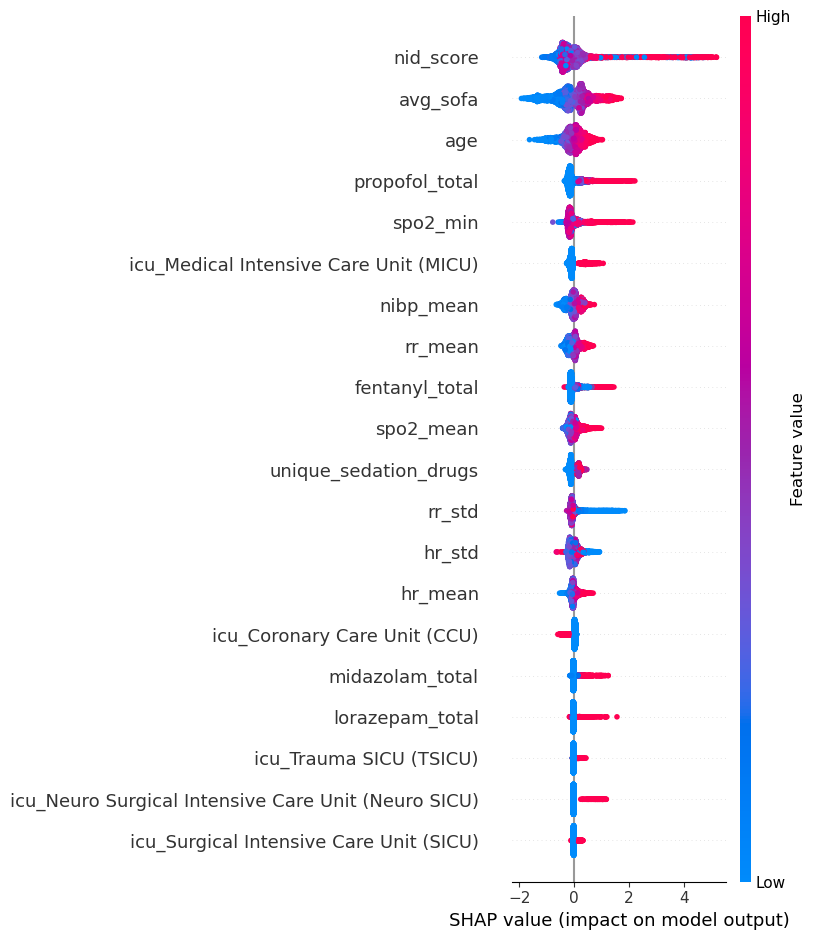

In [12]:
import shap
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
plt.figure()
shap.summary_plot(
    shap_values, 
    X_test,
    feature_names=X.columns.tolist(),
    max_display=20,
    show=True
)

In [13]:
# Check NID score distribution in v5
print("NID score stats:")
print(X['nid_score'].describe())
print("\nExtreme values (>0.8):", 
      (X['nid_score'] > 0.8).sum())
print("Values at exactly 1.0:", 
      (X['nid_score'] == 1.0).sum())

NID score stats:
count    25843.000000
mean         0.342797
std          0.098056
min          0.000000
25%          0.285800
50%          0.341000
75%          0.394600
max          0.955100
Name: nid_score, dtype: float64

Extreme values (>0.8): 45
Values at exactly 1.0: 0


In [14]:
# Ablation study — model without NID
X_train_no_nid = X_train.drop(columns=['nid_score'])
X_test_no_nid = X_test.drop(columns=['nid_score'])

xgb_no_nid = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=14028/11815,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb_no_nid.fit(X_train_no_nid, y_train)
y_pred_no_nid = xgb_no_nid.predict_proba(
    X_test_no_nid
)[:, 1]

auroc_no_nid = roc_auc_score(y_test, y_pred_no_nid)

print("=" * 45)
print(f"XGBoost WITH nid_score:    {auroc_xgb:.4f}")
print(f"XGBoost WITHOUT nid_score: {auroc_no_nid:.4f}")
print(f"NID contribution:          "
      f"+{auroc_xgb - auroc_no_nid:.4f} AUROC")
print("=" * 45)

XGBoost WITH nid_score:    0.8393
XGBoost WITHOUT nid_score: 0.8123
NID contribution:          +0.0270 AUROC


In [15]:
from scipy import stats

nid_delirious = X_test[y_test==1]['nid_score']
nid_not_delirious = X_test[y_test==0]['nid_score']

t_stat, p_value = stats.mannwhitneyu(
    nid_delirious, 
    nid_not_delirious,
    alternative='greater'
)

print(f"NID score — delirious patients:")
print(f"  Mean: {nid_delirious.mean():.4f}")
print(f"  Median: {nid_delirious.median():.4f}")
print(f"\nNID score — non-delirious patients:")
print(f"  Mean: {nid_not_delirious.mean():.4f}")
print(f"  Median: {nid_not_delirious.median():.4f}")

print(f"\nMann-Whitney U test:")
print(f"  p-value: {p_value:.6f}")
print(f"  Statistically significant: {p_value < 0.05}")

NID score — delirious patients:
  Mean: 0.3550
  Median: 0.3449

NID score — non-delirious patients:
  Mean: 0.3338
  Median: 0.3368

Mann-Whitney U test:
  p-value: 0.000000
  Statistically significant: True
